In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [2]:
import sys
sys.path.append('.')

from data_processing import DataProcessor

print("Модули успешно импортированы")

Модули успешно импортированы


In [3]:
processor = DataProcessor()

df = processor.load_data('dataset/dataset.csv')

print("=== СТРУКТУРА ДАННЫХ ===")
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")

print("\n=== ПЕРВЫЕ 5 СТРОК ===")
display(df.head())

Загружаем данные...
Загружено 1262 записей
=== СТРУКТУРА ДАННЫХ ===
Размер датасета: (1262, 29)
Колонки: ['product_url', 'product_guid', 'product_code', 'brand', 'model', 'color', 'price', 'old_price', 'installment_price', 'installment_monthly', 'diagonal_in', 'ram_gb', 'storage_gb', 'battery_mah', 'num_cameras', 'max_camera_mp', 'camera_list_mp', 'screen_type', 'resolution', 'has_nfc', 'has_5g', 'rating', 'reviews_count', 'availability', 'discount', 'img_url', 'specs_raw', 'price_segment', 'catalog_raw']

=== ПЕРВЫЕ 5 СТРОК ===


,product_url,product_guid,product_code,brand,model,color,price,old_price,installment_price,installment_monthly,diagonal_in,ram_gb,storage_gb,battery_mah,num_cameras,max_camera_mp,camera_list_mp,screen_type,resolution,has_nfc,has_5g,rating,reviews_count,availability,discount,img_url,specs_raw,price_segment,catalog_raw
0,https://www.dns-shop.ru/product/308735c56f27d0...,308735c5-6f27-11ef-9271-0050569d0a4d,5491266,Apple,iPhone 16 Pro Max,черный,127399,159299.0,6637 ₽/мес,6637,6.90,8.0,256,NaN,3.0,48.0,"48,48,12",Super Retina XDR,2868x1320,1,1,4.74,733.0,В наличии,-20%,https://c.dns-shop.ru/thumb/st1/fit/200/200/43...,"ядер - 6x(3.89 ГГц), 8 ГБ, 1 SIM, Super Retina...",flagship,{'product_guid': '308735c5-6f27-11ef-9271-0050...
1,https://www.dns-shop.ru/product/02247015da15d5...,02247015-da15-11ef-92d0-0050569d5825,5614256,Samsung,Galaxy S25 Ultra,черный,88999,NaN,8676 ₽/мес,8676,6.90,12.0,256,5000.0,4.0,200.0,"200,50,50,10",Dynamic AMOLED 2X,3120x1440,1,1,4.84,296.0,В наличии,NaN,https://c.dns-shop.ru/thumb/st1/fit/200/200/b8...,"ядер - 8x(4.47 ГГц), 12 ГБ, 2 SIM, Dynamic AMO...",flagship,{'product_guid': '02247015-da15-11ef-92d0-0050...
2,https://www.dns-shop.ru/product/00eb38374882ed...,00eb3837-4882-11ee-912e-00155d8ed20a,5430575,Apple,iPhone 15,черный,64199,72999.0,6083 ₽/мес,6083,6.10,6.0,128,3349.0,2.0,48.0,"48,12",Super Retina XDR,2556x1179,1,1,4.82,2700.0,В наличии,-12%,https://c.dns-shop.ru/thumb/st1/fit/200/200/69...,"ядер - 6x(3.46 ГГц), 6 ГБ, 1 SIM, Super Retina...",flagship,{'product_guid': '00eb3837-4882-11ee-912e-0015...
3,https://www.dns-shop.ru/product/7ffd0cf6a89cd2...,7ffd0cf6-a89c-11ef-92a1-0050569d21a3,5606794,Xiaomi,Redmi Note 14,черный,19699,NaN,1920 ₽/мес,1920,6.67,8.0,256,5500.0,3.0,108.0,"108,2,2",AMOLED,2400x1080,1,0,4.76,1600.0,В наличии,NaN,https://c.dns-shop.ru/thumb/st1/fit/200/200/66...,"ядер - 8x(2.2 ГГц), 8 ГБ, 2 SIM, AMOLED, 2400x...",mid-range,{'product_guid': '7ffd0cf6-a89c-11ef-92a1-0050...
4,https://www.dns-shop.ru/product/ff782fea6f26d0...,ff782fea-6f26-11ef-9271-0050569d0a4d,5491212,Apple,iPhone 16 Pro,черный,118799,148499.0,6187 ₽/мес,6187,6.30,8.0,256,NaN,3.0,48.0,"48,48,12",Super Retina XDR,2622x1206,1,1,4.81,960.0,В наличии,-20%,https://c.dns-shop.ru/thumb/st1/fit/200/200/ed...,"ядер - 6x(3.89 ГГц), 8 ГБ, 1 SIM, Super Retina...",flagship,{'product_guid': 'ff782fea-6f26-11ef-9271-0050...


In [4]:
print("=== ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ ===")

print(f"Общее количество записей: {len(df)}")
print(f"Количество признаков: {len(df.columns)}")
print("\nТипы данных:")
print(df.dtypes)

print("\n=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент': missing_percent
})
print(missing_info[missing_info['Пропущено'] > 0])

print("\n=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(df.describe())

=== ОСНОВНАЯ ИНФОРМАЦИЯ О ДАННЫХ ===
Общее количество записей: 1262
Количество признаков: 29

Типы данных:
product_url             object
product_guid            object
product_code             int64
brand                   object
model                   object
color                   object
price                    int64
old_price              float64
installment_price       object
installment_monthly      int64
diagonal_in            float64
ram_gb                 float64
storage_gb               int64
battery_mah            float64
num_cameras            float64
max_camera_mp          float64
camera_list_mp          object
screen_type             object
resolution              object
has_nfc                  int64
has_5g                   int64
rating                 float64
reviews_count          float64
availability            object
discount                object
img_url                 object
specs_raw               object
price_segment           object
catalog_raw             o

In [5]:
print("=== СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (value_category) ===")

def calculate_value_score(price, old_price, rating, ram, storage, max_camera_mp, has_5g):
    feature_score = (ram * 1000 + storage * 50 + max_camera_mp * 100 + (1000 if has_5g else 0))
    discount_factor = 1.0
    if old_price and old_price > price:
        discount_factor = 1 + (old_price - price) / old_price
    rating_factor = (rating - 3) / 2 if rating else 0.5
    value_score = discount_factor * (feature_score / price) * rating_factor
    return value_score

def create_categories(value_score):
    if value_score > 0.3:
        return 'exceptional_value'
    elif value_score > 0.2:
        return 'great_value'
    elif value_score > 0.1:
        return 'good_value'
    elif value_score > 0.05:
        return 'average_value'
    else:
        return 'poor_value'
df['value_score'] = df.apply(
    lambda row: calculate_value_score(
        row['price'], row['old_price'], row['rating'],
        row['ram_gb'], row['storage_gb'], row['max_camera_mp'],
        row['has_5g'] if 'has_5g' in df.columns else 0
    ), axis=1
)
df['value_category'] = df['value_score'].apply(create_categories)

print("Создание целевой переменной завершено")
print(f"Уникальные категории: {df['value_category'].unique()}")

=== СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (value_category) ===
Создание целевой переменной завершено
Уникальные категории: ['great_value' 'exceptional_value' 'poor_value' 'good_value']


=== АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (value_category) ===


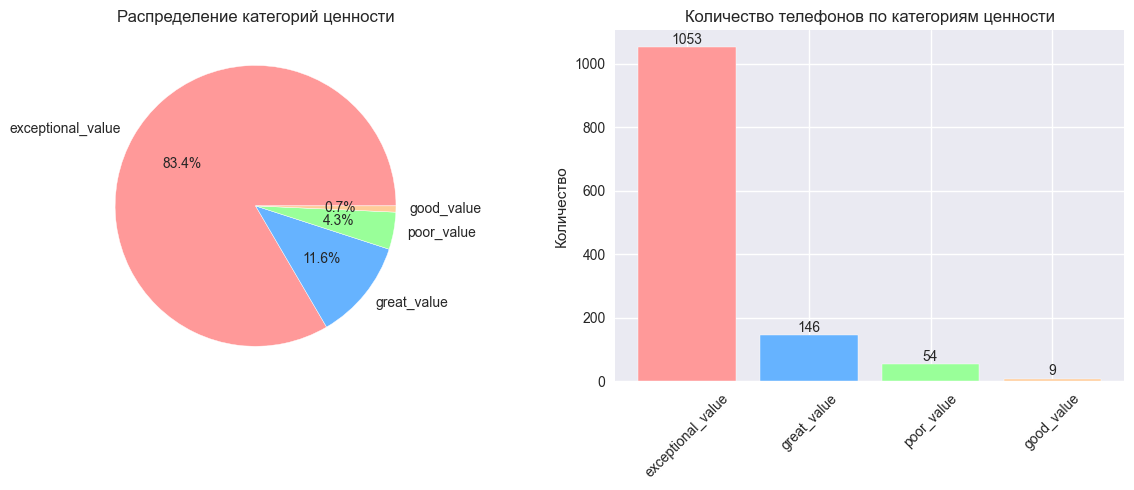

Статистика по категориям:
value_category
exceptional_value    1053
great_value           146
poor_value             54
good_value              9
Name: count, dtype: int64


In [6]:
print("=== АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (value_category) ===")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
value_counts = df['value_category'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Распределение категорий ценности')

plt.subplot(1, 2, 2)
plt.bar(value_counts.index, value_counts.values, color=colors)
plt.title('Количество телефонов по категориям ценности')
plt.xticks(rotation=45)
plt.ylabel('Количество')

for i, v in enumerate(value_counts.values):
    plt.text(i, v + 0.5, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Статистика по категориям:")
print(value_counts)

=== АНАЛИЗ ЦЕН ===


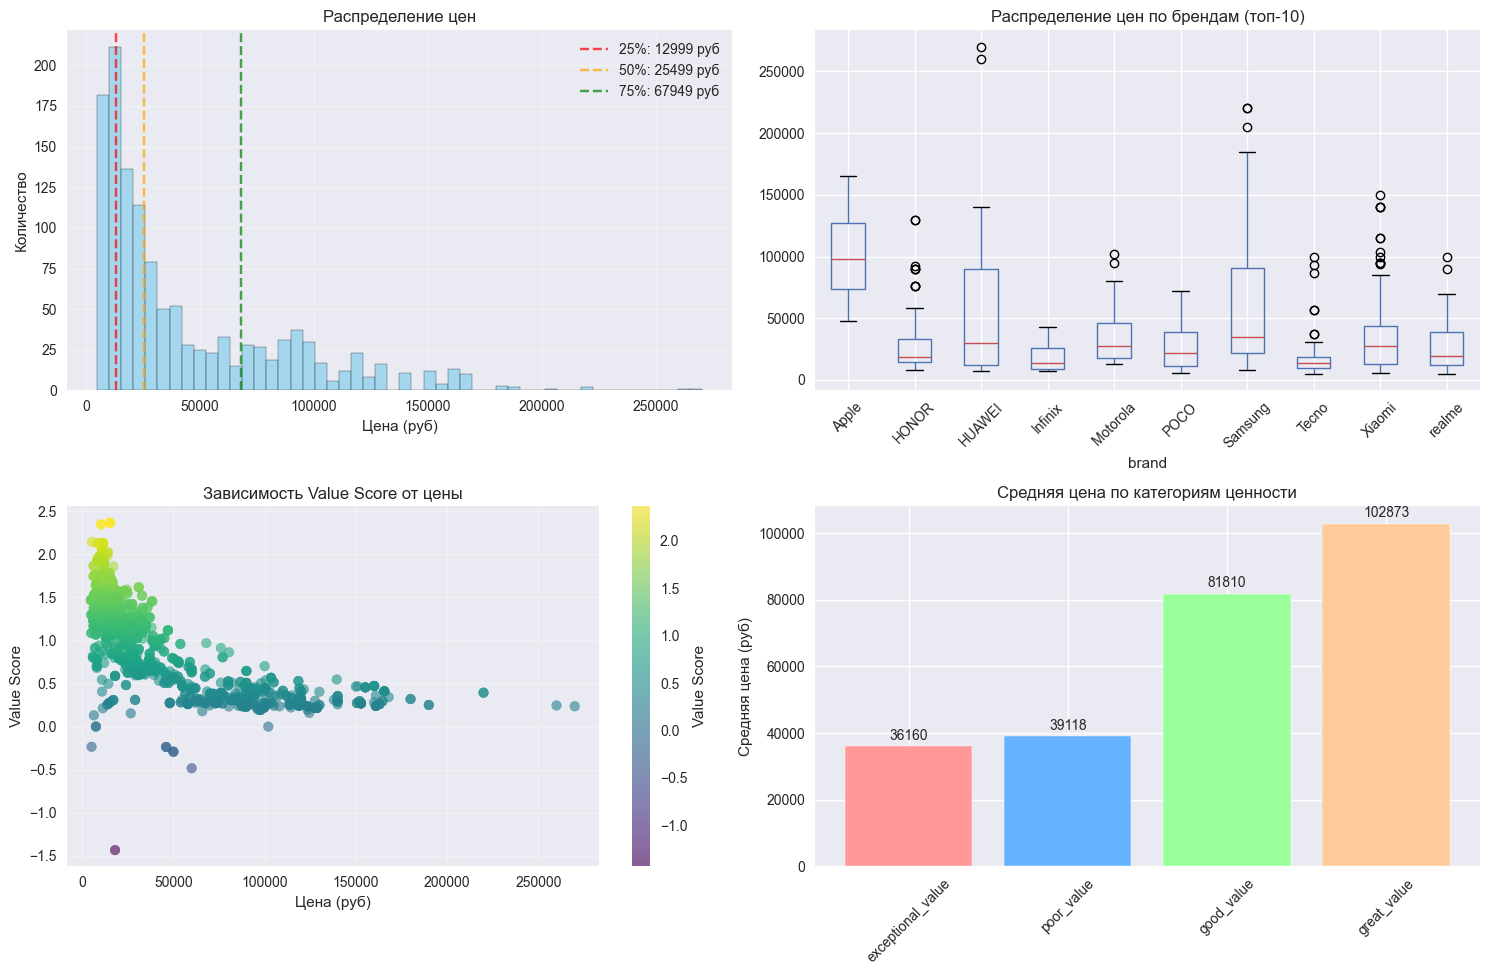


Ценовая статистика:
Минимальная цена: 4799 руб
Максимальная цена: 269999 руб
Средняя цена: 44330 руб
Медианная цена: 25499 руб


In [7]:
print("=== АНАЛИЗ ЦЕН ===")

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение цен')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)

price_25 = df['price'].quantile(0.25)
price_50 = df['price'].quantile(0.50)
price_75 = df['price'].quantile(0.75)
plt.axvline(price_25, color='red', linestyle='--', alpha=0.7, label=f'25%: {price_25:.0f} руб')
plt.axvline(price_50, color='orange', linestyle='--', alpha=0.7, label=f'50%: {price_50:.0f} руб')
plt.axvline(price_75, color='green', linestyle='--', alpha=0.7, label=f'75%: {price_75:.0f} руб')
plt.legend()

plt.subplot(2, 2, 2)
top_brands = df['brand'].value_counts().head(10).index
df_top_brands = df[df['brand'].isin(top_brands)]
df_top_brands.boxplot(column='price', by='brand', ax=plt.gca())
plt.title('Распределение цен по брендам (топ-10)')
plt.suptitle('')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
plt.scatter(df['price'], df['value_score'], alpha=0.6, c=df['value_score'], cmap='viridis')
plt.colorbar(label='Value Score')
plt.title('Зависимость Value Score от цены')
plt.xlabel('Цена (руб)')
plt.ylabel('Value Score')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
avg_price_by_category = df.groupby('value_category')['price'].mean().sort_values()
plt.bar(avg_price_by_category.index, avg_price_by_category.values, color=colors)
plt.title('Средняя цена по категориям ценности')
plt.ylabel('Средняя цена (руб)')
plt.xticks(rotation=45)

for i, v in enumerate(avg_price_by_category.values):
    plt.text(i, v + 1000, f'{v:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nЦеновая статистика:")
print(f"Минимальная цена: {df['price'].min():.0f} руб")
print(f"Максимальная цена: {df['price'].max():.0f} руб")
print(f"Средняя цена: {df['price'].mean():.0f} руб")
print(f"Медианная цена: {df['price'].median():.0f} руб")

=== АНАЛИЗ ТЕХНИЧЕСКИХ ХАРАКТЕРИСТИК ===


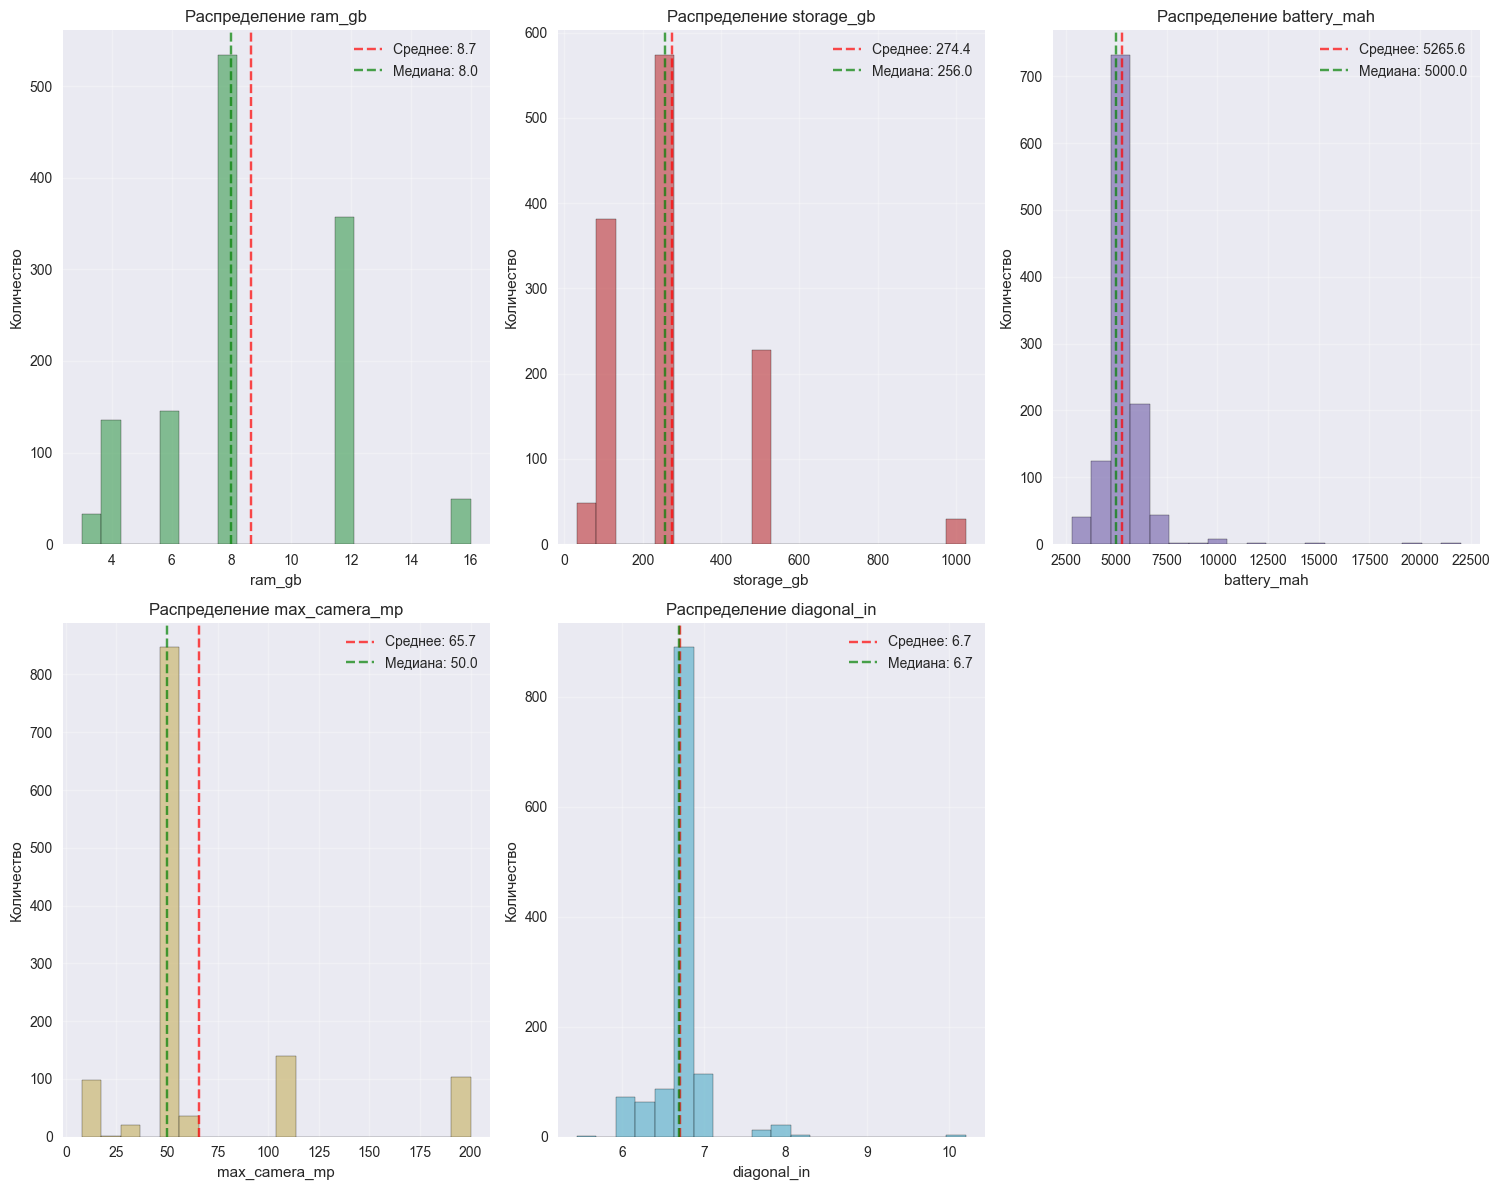


Статистика по техническим характеристикам:

ram_gb:
  Минимум: 3.0
  Максимум: 16.0
  Среднее: 8.7
  Медиана: 8.0

storage_gb:
  Минимум: 32
  Максимум: 1024
  Среднее: 274.4
  Медиана: 256.0

battery_mah:
  Минимум: 2815.0
  Максимум: 22000.0
  Среднее: 5265.6
  Медиана: 5000.0

max_camera_mp:
  Минимум: 8.0
  Максимум: 200.0
  Среднее: 65.7
  Медиана: 50.0

diagonal_in:
  Минимум: 5.45
  Максимум: 10.2
  Среднее: 6.7
  Медиана: 6.7


In [8]:
print("=== АНАЛИЗ ТЕХНИЧЕСКИХ ХАРАКТЕРИСТИК ===")

technical_features = ['ram_gb', 'storage_gb', 'battery_mah', 'max_camera_mp', 'diagonal_in']

plt.figure(figsize=(15, 12))

for i, feature in enumerate(technical_features, 1):
    plt.subplot(2, 3, i)

    if feature in df.columns:
        data = df[feature].dropna()

        plt.hist(data, bins=20, alpha=0.7, color=f'C{i}', edgecolor='black')
        plt.title(f'Распределение {feature}')
        plt.xlabel(feature)
        plt.ylabel('Количество')

        mean_val = data.mean()
        median_val = data.median()
        plt.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Среднее: {mean_val:.1f}')
        plt.axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Медиана: {median_val:.1f}')
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        plt.text(0.5, 0.5, f'{feature} не найден', ha='center', va='center', transform=plt.gca().transAxes)
        plt.title(f'Распределение {feature}')

plt.tight_layout()
plt.show()

print("\nСтатистика по техническим характеристикам:")
for feature in technical_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        print(f"  Минимум: {df[feature].min()}")
        print(f"  Максимум: {df[feature].max()}")
        print(f"  Среднее: {df[feature].mean():.1f}")
        print(f"  Медиана: {df[feature].median()}")

=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===


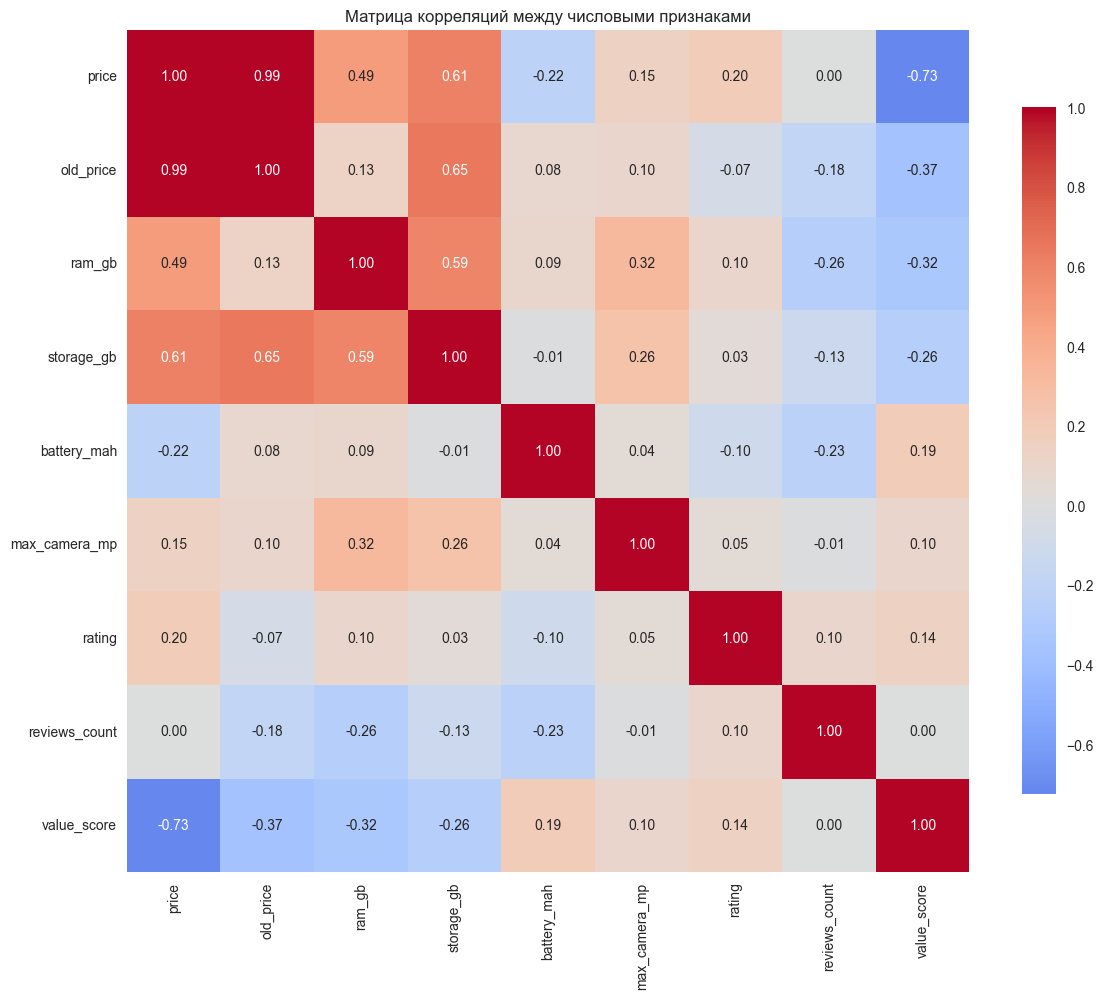


Корреляция признаков с Value Score:
  battery_mah: 0.191
  rating: 0.139
  max_camera_mp: 0.104
  reviews_count: 0.002
  storage_gb: -0.260
  ram_gb: -0.325
  old_price: -0.372
  price: -0.725


In [9]:
print("=== КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ===")

numeric_columns = ['price', 'old_price', 'ram_gb', 'storage_gb', 'battery_mah',
                  'max_camera_mp', 'rating', 'reviews_count', 'value_score']

existing_numeric = [col for col in numeric_columns if col in df.columns]

correlation_matrix = df[existing_numeric].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8})
plt.title('Матрица корреляций между числовыми признаками')
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с Value Score:")
value_score_corr = correlation_matrix['value_score'].sort_values(ascending=False)
for feature, corr in value_score_corr.items():
    if feature != 'value_score':
        print(f"  {feature}: {corr:.3f}")

=== АНАЛИЗ ПО БРЕНДАМ ===


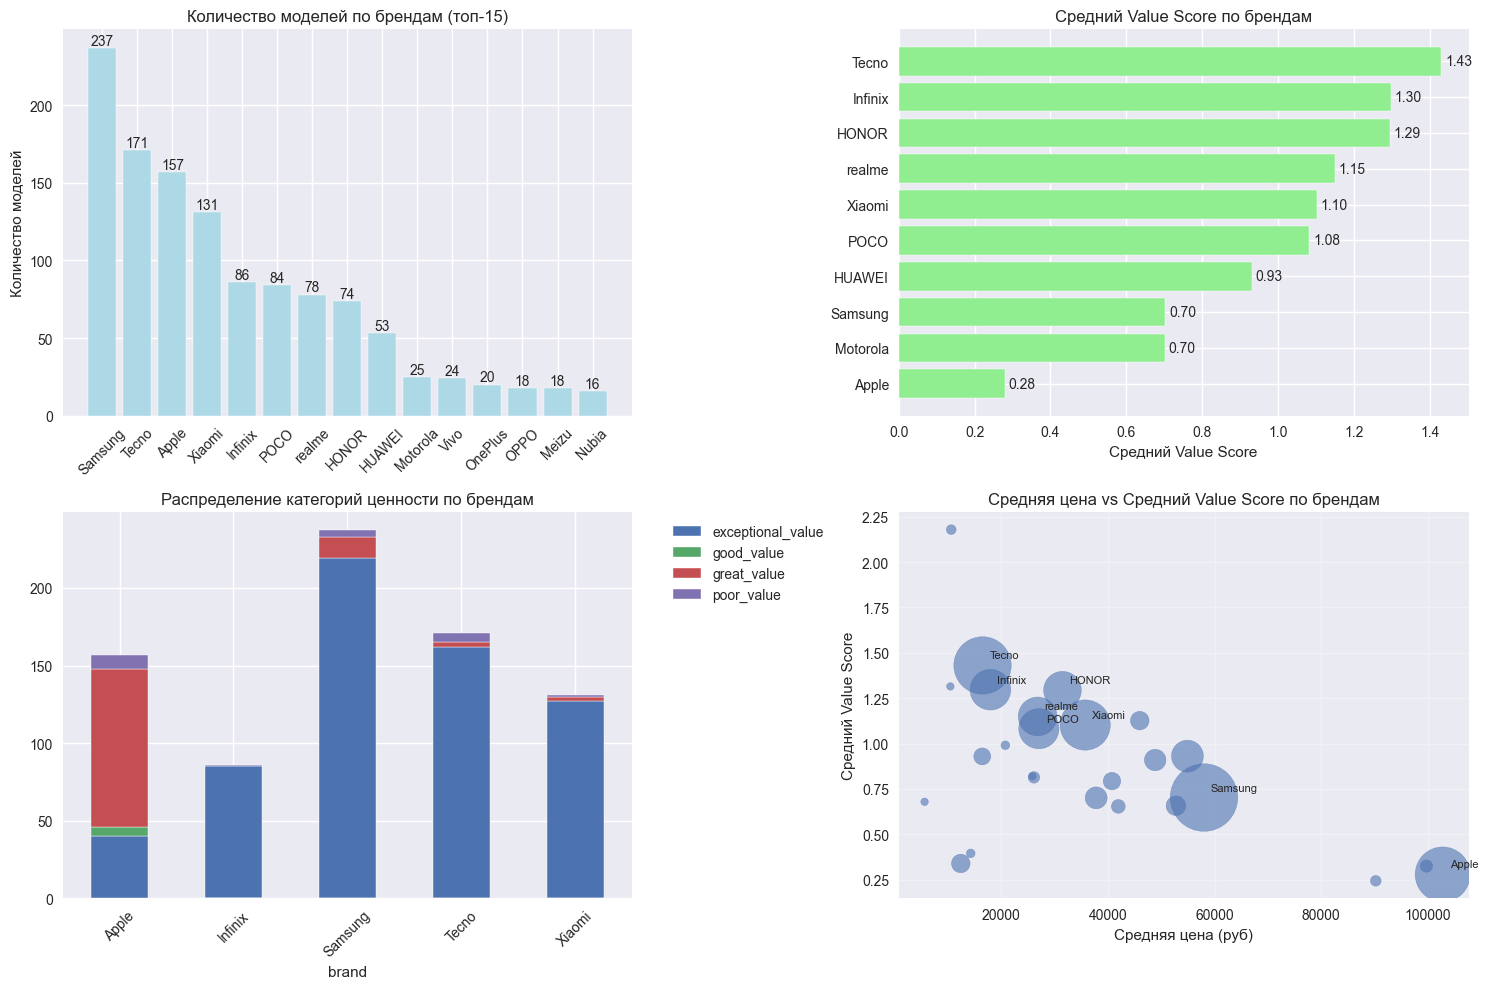


=== ПРИМЕРЫ ТЕЛЕФОНОВ ИЗ КАЖДОЙ КАТЕГОРИИ ===

--- POOR_VALUE ---
Apple iPhone 16e
  Цена: 54999 руб | Рейтинг: 4.88 | Батарея: nan mAh
  Память: nanGB/128GB | Камера: 48.0MP
  Value Score: nan

Apple iPhone 16e
  Цена: 59799 руб | Рейтинг: 4.88 | Батарея: nan mAh
  Память: nanGB/128GB | Камера: 48.0MP
  Value Score: nan

Apple iPhone 16e
  Цена: 68399 руб | Рейтинг: 4.88 | Батарея: nan mAh
  Память: nanGB/256GB | Камера: 48.0MP
  Value Score: nan


--- GOOD_VALUE ---
Apple iPhone 15 Pro Max
  Цена: 123499 руб | Рейтинг: 4.81 | Батарея: 4441.0 mAh
  Память: 8.0GB/256GB | Камера: 48.0MP
  Value Score: 0.195

Blackview BV9300 Pro
  Цена: 26599 руб | Рейтинг: 3.3 | Батарея: 15080.0 mAh
  Память: 8.0GB/256GB | Камера: 64.0MP
  Value Score: 0.153

Apple iPhone 15 Plus
  Цена: 97699 руб | Рейтинг: 4.84 | Батарея: 4383.0 mAh
  Память: 6.0GB/128GB | Камера: 48.0MP
  Value Score: 0.192


--- GREAT_VALUE ---
Apple iPhone 16 Pro Max
  Цена: 127399 руб | Рейтинг: 4.74 | Батарея: nan mAh
  Память:

In [10]:
print("=== АНАЛИЗ ПО БРЕНДАМ ===")

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
brand_counts = df['brand'].value_counts().head(15)
plt.bar(brand_counts.index, brand_counts.values, color='lightblue')
plt.title('Количество моделей по брендам (топ-15)')
plt.xticks(rotation=45)
plt.ylabel('Количество моделей')

for i, v in enumerate(brand_counts.values):
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom')

plt.subplot(2, 2, 2)
top_brands = df['brand'].value_counts().head(10).index
avg_value_by_brand = df[df['brand'].isin(top_brands)].groupby('brand')['value_score'].mean().sort_values(ascending=True)
plt.barh(avg_value_by_brand.index, avg_value_by_brand.values, color='lightgreen')
plt.title('Средний Value Score по брендам')
plt.xlabel('Средний Value Score')

for i, v in enumerate(avg_value_by_brand.values):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.subplot(2, 2, 3)
top_5_brands = df['brand'].value_counts().head(5).index
df_top_5 = df[df['brand'].isin(top_5_brands)]
cross_tab = pd.crosstab(df_top_5['brand'], df_top_5['value_category'])
cross_tab.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Распределение категорий ценности по брендам')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(2, 2, 4)
brand_stats = df.groupby('brand').agg({
    'price': 'mean',
    'value_score': 'mean',
    'model': 'count'
}).rename(columns={'model': 'count'})
brand_stats = brand_stats[brand_stats['count'] >= 3]

plt.scatter(brand_stats['price'], brand_stats['value_score'], s=brand_stats['count']*10, alpha=0.6)
plt.title('Средняя цена vs Средний Value Score по брендам')
plt.xlabel('Средняя цена (руб)')
plt.ylabel('Средний Value Score')

large_brands = brand_stats[brand_stats['count'] > brand_stats['count'].quantile(0.7)]
for brand, row in large_brands.iterrows():
    plt.annotate(brand, (row['price'], row['value_score']),
                 xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== ПРИМЕРЫ ТЕЛЕФОНОВ ИЗ КАЖДОЙ КАТЕГОРИИ ===")

for category in ['poor_value', 'good_value', 'great_value', 'exceptional_value']:
    print(f"\n--- {category.upper()} ---")
    examples = df[df['value_category'] == category][[
        'brand', 'model', 'price', 'rating', 'battery_mah', 'ram_gb', 'storage_gb', 'max_camera_mp', 'value_score'
    ]].head(3)

    for idx, row in examples.iterrows():
        print(f"{row['brand']} {row['model']}")
        print(f"  Цена: {row['price']} руб | Рейтинг: {row['rating']} | Батарея: {row['battery_mah']} mAh")
        print(f"  Память: {row['ram_gb']}GB/{row['storage_gb']}GB | Камера: {row['max_camera_mp']}MP")
        print(f"  Value Score: {row['value_score']:.3f}")
        print()

In [11]:
print("Выводы:")
print("1. Сильный дисбаланс классов: 83.4% - exceptional_value")
print("2. Формула value_score слишком агрессивна: наказывает дорогие телефоны")
print("3. Много пропущенных значений: особенно old_price (85%)")
print("")
print("Вывод:")
print("- Пересмотреть формулу value_score")

Выводы:
1. Сильный дисбаланс классов: 83.4% - exceptional_value
2. Формула value_score слишком агрессивна: наказывает дорогие телефоны
3. Много пропущенных значений: особенно old_price (85%)

Вывод:
- Пересмотреть формулу value_score
